In [90]:
import numpy as np
import pandas as pd
import os
import pathlib

from tqdm import tqdm
import warnings

from skimage import util
from skimage.filters import threshold_otsu, gaussian, threshold_isodata, threshold_minimum, threshold_triangle, threshold_otsu, threshold_mean, threshold_li, try_all_threshold, threshold_yen
from skimage.segmentation import clear_border, watershed
from skimage.measure import label, regionprops, regionprops_table
from skimage.morphology import remove_small_holes, remove_small_objects, opening, ball, dilation, erosion
from skimage.transform import rescale
from skimage.feature import peak_local_max
import matplotlib.pyplot as plt
from scipy.ndimage import distance_transform_edt
from scipy import ndimage as ndi

from skimage.filters import median as median_filter
from skimage.morphology import square
from tifffile import imread
import tifffile

import napari

warnings.filterwarnings("ignore")

In [ ]:

import liffile

lif_path = r"z:\Marina\Stellaris\2026.03.10_CART\CART_FL12_ToQuantify\CART_exp1_day6.lif"

with liffile.LifFile(lif_path) as lif:
    img = lif.images[0]
    print(f"Name:  {img.name}")
    print(f"dims:  {img.dims}")
    print(f"shape: {img.shape}")
    data = img.asarray()

print(f"\nLoaded array shape: {data.shape}")


Name:  FL12_day6_ARi1
dims:  ('C', 'Z', 'Y', 'X')
shape: (5, 33, 2780, 4752)

Loaded array shape: (5, 33, 2780, 4752)
test shape (after Z max-projection): (5, 1, 2780, 4752)
Axes order: ('C', 'Z', 'Y', 'X')  →  Z axis 1 collapsed to 1


In [10]:

# Max-project along the Z axis (keepdims so Z dim stays as 1)
z_axis = img.dims.index('Z')
test_sum = np.sum(data, axis=z_axis, keepdims=True)
test_max = np.max(data, axis=z_axis, keepdims=True)
print(f"test shape (after Z max-projection): {test_sum.shape}")
print(f"Axes order: {img.dims}  →  Z axis {z_axis} collapsed to 1")


test shape (after Z max-projection): (5, 1, 2780, 4752)
Axes order: ('C', 'Z', 'Y', 'X')  →  Z axis 1 collapsed to 1


In [13]:
test_sum.shape

(5, 1, 2780, 4752)

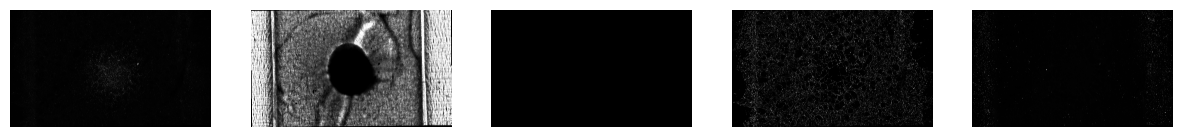

In [20]:
fig , ax = plt.subplots(ncols = test_sum.shape[0], figsize=(15,3))
channel = 0  # change to 0-4 to pick a channel
for i in range(test_sum.shape[0]):
    ax[i].imshow(test_sum[i, 0, :, :], cmap='gray')
    ax[i].axis('off')

In [78]:
vasculature = test_max[3, 0, :, :]
vasculature_median = median_filter(vasculature, footprint=square(7))
smooth_vasculature = gaussian(vasculature_median, sigma=3)
segmented_vasculature = smooth_vasculature>threshold_triangle(smooth_vasculature)

In [79]:
device = test_max[1, 0, :, :]
clipped = np.clip(device, np.percentile(device, 25), np.percentile(device, 90))
smoothed = gaussian(clipped, sigma=7)
gel = util.invert(smoothed > threshold_mean(smoothed))
gel = remove_small_holes(gel, max_size=500000)

# Keep only the largest connected component
labeled_gel = label(gel)
props = pd.DataFrame(regionprops_table(labeled_gel, properties=("label", "area")))
largest_label = props.loc[props["area"].idxmax(), "label"]
gel = labeled_gel == largest_label


In [91]:
tcells = test_max[0, 0, :, :]
segmented_t_cells = tcells > threshold_yen(tcells)

skimage.filters.thresholding.threshold_isodata
skimage.filters.thresholding.threshold_li
skimage.filters.thresholding.threshold_mean
skimage.filters.thresholding.threshold_minimum
skimage.filters.thresholding.threshold_otsu
skimage.filters.thresholding.threshold_triangle
skimage.filters.thresholding.threshold_yen


(<Figure size 800x500 with 8 Axes>,
 array([<Axes: title={'center': 'Original'}>,
        <Axes: title={'center': 'Isodata'}>,
        <Axes: title={'center': 'Li'}>, <Axes: title={'center': 'Mean'}>,
        <Axes: title={'center': 'Minimum'}>,
        <Axes: title={'center': 'Otsu'}>,
        <Axes: title={'center': 'Triangle'}>,
        <Axes: title={'center': 'Yen'}>], dtype=object))

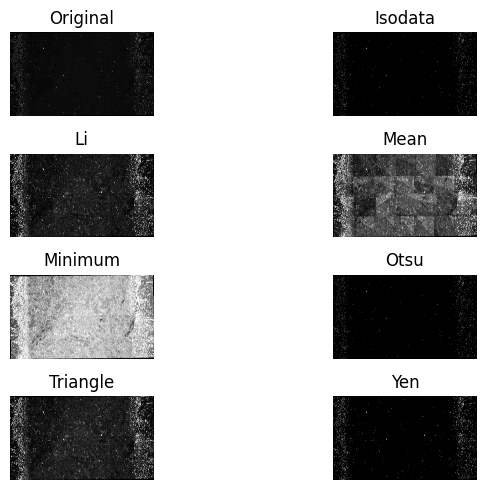

In [ ]:
cart = test_max[-1, 0, :, :]
try_all_threshold(cart)

In [89]:
tumour = device < threshold_minimum(device)
labeled_tumour = label(tumour)
props = pd.DataFrame(regionprops_table(labeled_tumour, properties=("label", "area")))
largest_label = props.loc[props["area"].idxmax(), "label"]
tumour = labeled_tumour == largest_label


In [94]:
viewer = napari.Viewer()
viewer.add_image(test_max)
viewer.add_labels(gel)
viewer.add_labels(segmented_vasculature)
viewer.add_labels(tumour)
viewer.add_labels(segmented_t_cells)
viewer.add_labels(cart> threshold_yen(cart), name="yen")
viewer.add_labels(cart> threshold_otsu(cart), name="otsu")

<Labels layer 'otsu' at 0x1191b34bdd0>